## Install n Imports :)

In [29]:
!pip install pandas numpy scikit-learn torch matplotlib -q

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from datetime import datetime

## CELL 2: Load Z2 outputs (data + predictions)

In [30]:
try:
    merged = pd.read_parquet("/kaggle/input/datasets/sohamjangra/bilstm-weights/merged_5min.parquet")
    preds = np.load("/kaggle/input/datasets/sohamjangra/bilstm-weights/predictions_5min.npz")
    p_train = preds["p_train"]
    p_val   = preds["p_val"]
    p_test  = preds["p_test"]
    print(f' Loaded data: merged {merged.shape}')
    print(f' Loaded predictions: train {len(p_train)}, val {len(p_val)}, test {len(p_test)}')
except:
    print(' Files not found. Make sure you ran Z2 first and saved outputs to /kaggle/working/')
    print('   Run Z2 Cell 8-9 to generate these files.')
    raise

SEQ_LEN = 78
BARS_PER_DAY = 288
FEE_PCT = 0.0004
CAPITAL = 10_000

 Loaded data: merged (368333, 28)
 Loaded predictions: train 262285, val 52914, test 52050


## CELL 3: Build train/val/test dataframes with predictions

In [31]:
df_train_s = merged.loc["2023-01-01":"2025-06-30"].iloc[SEQ_LEN:].copy()
df_train_s = df_train_s.iloc[:len(p_train)]
df_train_s["pred_vol"] = p_train[:len(df_train_s)]

df_val_s = merged.loc["2025-07-01":"2025-12-31"].iloc[SEQ_LEN:].copy()
df_val_s = df_val_s.iloc[:len(p_val)]
df_val_s["pred_vol"] = p_val[:len(df_val_s)]

df_test_s = merged.loc["2026-01-01":"2026-06-30"].iloc[SEQ_LEN:].copy()
df_test_s = df_test_s.iloc[:len(p_test)]
df_test_s["pred_vol"] = p_test[:len(df_test_s)]

print(f'Train: {len(df_train_s):,} bars  {df_train_s.index[0]} → {df_train_s.index[-1]}')
print(f'Val:   {len(df_val_s):,} bars  {df_val_s.index[0]} → {df_val_s.index[-1]}')
print(f'Test:  {len(df_test_s):,} bars  {df_test_s.index[0]} → {df_test_s.index[-1]}')

Train: 262,285 bars  2023-01-02 06:55:00 → 2025-06-30 23:55:00
Val:   52,914 bars  2025-07-01 06:30:00 → 2025-12-31 23:55:00
Test:  52,050 bars  2026-01-01 06:30:00 → 2026-06-30 23:55:00


## CELL 4: Compute log returns

In [32]:
df_train_s["log_ret"] = np.log(df_train_s["close"] / df_train_s["close"].shift(1))
df_val_s["log_ret"]   = np.log(df_val_s["close"]   / df_val_s["close"].shift(1))
df_test_s["log_ret"]  = np.log(df_test_s["close"]  / df_test_s["close"].shift(1))

print(f'Train log returns: μ={df_train_s["log_ret"].mean()*288*100:.2f}% annualized')
print(f'Val log returns:   μ={df_val_s["log_ret"].mean()*288*100:.2f}% annualized')
print(f'Test log returns:  μ={df_test_s["log_ret"].mean()*288*100:.2f}% annualized')

Train log returns: μ=0.20% annualized
Val log returns:   μ=-0.11% annualized
Test log returns:  μ=-0.22% annualized


## CELL 5: Aggregate 5-min → 6H bars + attach pred_vol

In [33]:
def resample_6H(df):
    """OHLCV resampled to 6H. pred_vol = last 5-min prediction in window."""
    ohlcv = df['close'].resample('6h').ohlc()
    ohlcv.columns = ['open','high','low','close']
    ohlcv['volume']   = df['volume'].resample('6h').sum()
    ohlcv['pred_vol'] = df['pred_vol'].resample('6h').last()  # most recent forecast
    return ohlcv.dropna()

df_train_6h = resample_6H(df_train_s)
df_val_6h   = resample_6H(df_val_s)
df_test_6h  = resample_6H(df_test_s)

print(f'6H bars — Train: {len(df_train_6h):,}  Val: {len(df_val_6h):,}  Test: {len(df_test_6h):,}')
print(f'Train: {df_train_6h.index[0]} → {df_train_6h.index[-1]}')
print(f'Val:   {df_val_6h.index[0]} → {df_val_6h.index[-1]}')
print(f'Test:  {df_test_6h.index[0]} → {df_test_6h.index[-1]}')

MEDIAN_PV_TRAIN = float(np.median(df_train_6h['pred_vol'].dropna()))
print(f'\nMedian pred_vol (TRAIN): {MEDIAN_PV_TRAIN:.6f}')

6H bars — Train: 3,643  Val: 735  Test: 723
Train: 2023-01-02 06:00:00 → 2025-06-30 18:00:00
Val:   2025-07-01 06:00:00 → 2025-12-31 18:00:00
Test:  2026-01-01 06:00:00 → 2026-06-30 18:00:00

Median pred_vol (TRAIN): 0.001574


## CELL 6: Compute 6H features (EMA trend + ATR)

In [34]:
def add_features_6h(df, ema_period=20, atr_period=14):
    """EMA for trend signal, ATR for stop distance."""
    df = df.copy()
    df['EMA'] = df['close'].ewm(span=ema_period, adjust=False).mean()
    tr = pd.concat([
        df['high'] - df['low'],
        (df['high'] - df['close'].shift(1)).abs(),
        (df['low']  - df['close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    df['ATR'] = tr.rolling(atr_period).mean()
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
    df['vol_factor'] = df['pred_vol'] / (MEDIAN_PV_TRAIN + 1e-12)
    df['vol_factor'] = df['vol_factor'].clip(0.5, 3.0)
    return df.dropna()

df_train_6h = add_features_6h(df_train_6h)
df_val_6h   = add_features_6h(df_val_6h)
df_test_6h  = add_features_6h(df_test_6h)

print(f'After feature engineering:')
print(f'  Train: {len(df_train_6h)} bars')
print(f'  Val:   {len(df_val_6h)} bars')
print(f'  Test:  {len(df_test_6h)} bars')
print(f'\nvol_factor stats (TRAIN):')
print(f'  mean={df_train_6h["vol_factor"].mean():.3f}  '
      f'std={df_train_6h["vol_factor"].std():.3f}  '
      f'p10={df_train_6h["vol_factor"].quantile(0.1):.3f}  '
      f'p90={df_train_6h["vol_factor"].quantile(0.9):.3f}')

After feature engineering:
  Train: 3630 bars
  Val:   722 bars
  Test:  710 bars

vol_factor stats (TRAIN):
  mean=1.148  std=0.587  p10=0.509  p90=1.971


## CELL 7: AdaptiveTrend Strategy Function

In [35]:
def adaptive_trend(df, k, capital=10_000, fee_pct=0.0004, long_only=False):
    """
    AdaptiveTrend: EMA trend following with BiLSTM vol-adaptive trailing stop.

    Signal:  close > EMA → LONG,  close < EMA → SHORT (or flat if long_only)
    Stop:    trail by k × ATR × vol_factor
             vol_factor = pred_vol / median_train_pred_vol
             High vol → wider stop (avoid noise-outs in volatile rallies)
             Low vol  → tighter stop (lock in gains faster)

    k: ATR multiplier (selected on VAL)
    """
    closes     = df['close'].values
    emas       = df['EMA'].values
    atrs       = df['ATR'].values
    vol_factors= df['vol_factor'].values
    idx        = df.index

    position   = 0          # 1=long, -1=short, 0=flat
    entry_price= 0.0
    trail_stop = 0.0
    pnl        = []
    dates      = []
    trades     = []

    for i in range(1, len(df)):
        price = closes[i]
        ema   = emas[i]
        atr   = atrs[i]
        vf    = vol_factors[i]
        qty   = capital / price

        if position == 1:
            new_stop = price - k * atr * vf
            trail_stop = max(trail_stop, new_stop)  # only ratchet up
        elif position == -1:
            new_stop = price + k * atr * vf
            trail_stop = min(trail_stop, new_stop)  # only ratchet down

        exited = False
        if position == 1 and price < trail_stop:
            gross = (price - entry_price) * qty
            fee   = fee_pct * qty * (entry_price + price)
            pnl.append(gross - fee)
            trades.append({'entry': entry_price, 'exit': price,
                           'dir': 1, 'pnl': gross - fee, 'date': idx[i]})
            position = 0; exited = True
        elif position == -1 and price > trail_stop:
            gross = (entry_price - price) * qty
            fee   = fee_pct * qty * (entry_price + price)
            pnl.append(gross - fee)
            trades.append({'entry': entry_price, 'exit': price,
                           'dir': -1, 'pnl': gross - fee, 'date': idx[i]})
            position = 0; exited = True

        if position == 0 or exited:
            if price > ema:  # uptrend → long
                if position != 1:
                    entry_price = price
                    trail_stop  = price - k * atr * vf
                    position = 1
            elif not long_only and price < ema:  # downtrend → short
                if position != -1:
                    if position == 1:
                        gross = (price - entry_price) * qty
                        fee   = fee_pct * qty * (entry_price + price)
                        pnl.append(gross - fee)
                        trades.append({'entry': entry_price, 'exit': price,
                                       'dir': 1, 'pnl': gross - fee, 'date': idx[i]})
                    entry_price = price
                    trail_stop  = price + k * atr * vf
                    position = -1

        dates.append(idx[i])

    if position != 0:
        price = closes[-1]
        qty   = capital / closes[-1]
        gross = (price - entry_price) * position * qty
        fee   = fee_pct * qty * (entry_price + price)
        pnl.append(gross - fee)
        trades.append({'entry': entry_price, 'exit': price,
                       'dir': position, 'pnl': gross - fee, 'date': idx[-1]})

    pnl = np.array(pnl)
    eq  = capital + np.cumsum(pnl)

    BARS_PER_YEAR = 4 * 365
    if len(pnl) > 1:
        sharpe = float(pnl.mean() / (pnl.std() + 1e-12) * np.sqrt(BARS_PER_YEAR))
    else:
        sharpe = 0.0
    wr = float((pnl > 0).mean()) if len(pnl) > 0 else 0.0
    max_dd = float((eq - np.maximum.accumulate(eq)).min() / capital * 100)

    return {
        'sharpe':   round(sharpe, 3),
        'pnl':      round(float(eq[-1] - capital), 2) if len(eq)>0 else 0,
        'ret':      round(float((eq[-1]/capital - 1)*100), 2) if len(eq)>0 else 0,
        'max_dd':   round(max_dd, 2),
        'wr':       round(wr, 3),
        'n_trades': len(trades),
        'fees':     round(sum(fee_pct*capital*0.0002 for _ in trades), 2),
    }, pnl, trades, eq

print(' AdaptiveTrend strategy function defined')

 AdaptiveTrend strategy function defined


In [36]:
def adaptive_trend_barwise(df, k, capital=10_000, fee_pct=0.0004, long_only=False):
    """Bar-by-bar PnL — correct Sharpe computation."""
    closes      = df['close'].values
    emas        = df['EMA'].values
    atrs        = df['ATR'].values
    vol_factors = df['vol_factor'].values

    position    = 0
    entry_price = 0.0
    trail_stop  = 0.0
    bar_pnl     = np.zeros(len(df))
    trades      = []

    for i in range(1, len(df)):
        price = closes[i]; ema = emas[i]; atr = atrs[i]; vf = vol_factors[i]
        qty   = capital / closes[0]

        if position == 1:
            trail_stop = max(trail_stop, price - k * atr * vf)
        elif position == -1:
            trail_stop = min(trail_stop, price + k * atr * vf)

        if position != 0:
            bar_pnl[i] = (closes[i] - closes[i-1]) * position * qty

        exited = False
        if position == 1 and price < trail_stop:
            fee = fee_pct * qty * (entry_price + price)
            bar_pnl[i] -= fee
            trades.append({'dir': 1, 'entry': entry_price, 'exit': price,
                          'pnl': (price-entry_price)*qty - fee})
            position = 0; exited = True
        elif position == -1 and price > trail_stop:
            fee = fee_pct * qty * (entry_price + price)
            bar_pnl[i] -= fee
            trades.append({'dir': -1, 'entry': entry_price, 'exit': price,
                          'pnl': (entry_price-price)*qty - fee})
            position = 0; exited = True

        if position == 0 or exited:
            if price > ema:
                if position != 1:
                    entry_price = price; trail_stop = price - k * atr * vf
                    position = 1; bar_pnl[i] -= fee_pct * qty * price
            elif price < ema:
                if position == 1:
                    bar_pnl[i] -= fee_pct * qty * price
                entry_price = price; trail_stop = price + k * atr * vf
                position = -1; bar_pnl[i] -= fee_pct * qty * price

    if position != 0:
        price = closes[-1]; qty = capital / closes[0]
        fee = fee_pct * qty * price
        bar_pnl[-1] += (closes[-1] - closes[-2]) * position * qty - fee
        trades.append({'dir': position, 'entry': entry_price, 'exit': price,
                      'pnl': (closes[-1]-entry_price)*position*qty - fee})

    eq = capital + np.cumsum(bar_pnl)
    bar_ret = bar_pnl / capital
    sharpe_bar = float(bar_ret.mean() / (bar_ret.std() + 1e-12) * np.sqrt(4*365))
    trade_pnls = np.array([t['pnl'] for t in trades])
    wr = round(float((trade_pnls > 0).mean()) if len(trade_pnls) > 0 else 0, 3)

    return {
        'sharpe_bar': round(sharpe_bar, 3),
        'pnl':        round(float(eq[-1] - capital), 2),
        'ret':        round(float((eq[-1]/capital - 1)*100), 2),
        'max_dd':     round(float((eq - np.maximum.accumulate(eq)).min()/capital*100), 2),
        'n_trades':   len(trades),
        'wr':         wr,
        'n_bars':     len(df),
    }, bar_pnl, trades, eq

print(f' adaptive_trend_barwise defined')

 adaptive_trend_barwise defined


## CELL 8: Sweep k on TRAIN (sanity check only)

In [37]:

print('TRAIN sanity check (k sweep — not used for selection)')
print(f'{"k":>5} {"Sharpe":>8} {"PnL":>9} {"Ret%":>7} {"Trades":>8} {"WR":>6} {"MaxDD%":>8}')
print('-'*55)

for k in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]:
    r, _, _, _ = adaptive_trend(df_train_6h, k)
    print(f'{k:>5.1f} {r["sharpe"]:>8.3f} {r["pnl"]:>9.0f} '
          f'{r["ret"]:>7.1f}% {r["n_trades"]:>8d} '
          f'{r["wr"]:>5.0%} {r["max_dd"]:>8.2f}%')

print('\nNote: TRAIN Sharpe will be high — expected for trend following.')
print('Selection happens on VAL only.')

TRAIN sanity check (k sweep — not used for selection)
    k   Sharpe       PnL    Ret%   Trades     WR   MaxDD%
-------------------------------------------------------
  0.5   -0.224     -1258   -12.6%      755   34%   -80.09%
  1.0    1.132      4430    44.3%      392   35%   -68.69%
  1.5    0.522      1681    16.8%      284   34%   -50.51%
  2.0    2.250      5663    56.6%      194   41%   -43.78%
  2.5    4.661     10395   104.0%      152   43%   -42.02%
  3.0    3.884      8144    81.4%      129   42%   -45.42%
  4.0    1.873      3721    37.2%       99   39%   -54.33%

Note: TRAIN Sharpe will be high — expected for trend following.
Selection happens on VAL only.


## CELL 9: VAL — select best k (only 1 param, selected once)

In [38]:
print('VAL k sweep — AdaptiveTrend (long-short)')
print(f'{"k":>5} {"Sharpe":>8} {"PnL":>9} {"Ret%":>7} {"Trades":>8} {"WR":>6} {"MaxDD%":>8}')
print('-'*55)

val_results = []
for k in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0, 4.0]:
    r, _, _, _ = adaptive_trend(df_val_6h, k)
    val_results.append((k, r))
    flag = '  ← realistic' if 0.5 <= r['sharpe'] <= 5.0 and r['n_trades'] >= 5 else ''
    print(f'{k:>5.2f} {r["sharpe"]:>8.3f} {r["pnl"]:>9.0f} '
          f'{r["ret"]:>7.1f}% {r["n_trades"]:>8d} '
          f'{r["wr"]:>5.0%} {r["max_dd"]:>8.2f}%{flag}')

valid = [(k, r) for k, r in val_results
         if r['n_trades'] >= 5 and r['sharpe'] > 0.0]

if valid:
    BEST_K = max(valid, key=lambda x: x[1]['sharpe'])[0]
    best_r = [r for k, r in val_results if k == BEST_K][0]
    print(f'\n Selected k = {BEST_K} (VAL Sharpe={best_r["sharpe"]}, '
          f'Trades={best_r["n_trades"]})')
else:
    BEST_K = max(val_results, key=lambda x: x[1]['sharpe'])[0]
    print(f'\n  No clearly positive VAL. Using k={BEST_K} (least negative)')

print(f'BEST_K = {BEST_K}  ← LOCKED. Test uses this, never changed.')

VAL k sweep — AdaptiveTrend (long-short)
    k   Sharpe       PnL    Ret%   Trades     WR   MaxDD%
-------------------------------------------------------
 0.50   -2.962     -2812   -28.1%      176   31%   -46.80%
 0.75   -4.378     -3672   -36.7%      134   29%   -43.10%
 1.00   -3.387     -2649   -26.5%      105   26%   -36.27%
 1.25   -4.643     -3296   -33.0%       90   26%   -40.69%
 1.50   -4.608     -2765   -27.6%       71   27%   -41.32%
 2.00   -1.570      -805    -8.1%       55   31%   -28.93%
 2.50    1.504       596     6.0%       38   42%   -16.99%  ← realistic
 3.00    2.302       725     7.2%       28   43%   -23.03%  ← realistic
 4.00    2.776       620     6.2%       18   61%   -16.91%  ← realistic

 Selected k = 4.0 (VAL Sharpe=2.776, Trades=18)
BEST_K = 4.0  ← LOCKED. Test uses this, never changed.


## CELL 10: TEST — run once with locked k

In [39]:
res_test, bar_pnl_test, trades_test, eq_test = adaptive_trend_barwise(df_test_6h, BEST_K)

bnh_ret       = df_test_6h['log_ret'].values
bnh_eq        = CAPITAL * np.exp(np.cumsum(bnh_ret))
bnh_sharpe    = float(bnh_ret.mean() / (bnh_ret.std() + 1e-12) * np.sqrt(4*365))
bnh_ret_total = float((bnh_eq[-1]/CAPITAL - 1) * 100)
bnh_max_dd    = float((bnh_eq - np.maximum.accumulate(bnh_eq)).min() / CAPITAL * 100)

print('\n' + '='*60)
print('ADAPTIVETREND — TEST (Jan-Jun 2026)')
print(f'k={BEST_K} locked from VAL. Zero leakage.')
print('='*60)
print(f'  Sharpe (bar-level): {res_test["sharpe_bar"]}')
print(f'  Net PnL:            ${res_test["pnl"]:.2f}')
print(f'  Return:             {res_test["ret"]:+.2f}%')
print(f'  Max DD:             {res_test["max_dd"]:.2f}%')
print(f'  Win Rate:           {res_test["wr"]:.0%}')
print(f'  Trades:             {res_test["n_trades"]}')
print('='*60)
print(f'\n  BUY & HOLD (bar-level):')
print(f'  Sharpe:             {bnh_sharpe:.3f}')
print(f'  Return:             {bnh_ret_total:+.2f}%')
print(f'  Max DD:             {bnh_max_dd:.2f}%')
print('='*60)
improvement = res_test["sharpe_bar"] - bnh_sharpe
print(f'\nAdaptiveTrend beats B&H by {improvement:+.3f} Sharpe (bar-level)')


ADAPTIVETREND — TEST (Jan-Jun 2026)
k=4.0 locked from VAL. Zero leakage.
  Sharpe (bar-level): 1.838
  Net PnL:            $3324.10
  Return:             +33.24%
  Max DD:             -20.68%
  Win Rate:           50%
  Trades:             16

  BUY & HOLD (bar-level):
  Sharpe:             -1.935
  Return:             -35.79%
  Max DD:             -42.21%

AdaptiveTrend beats B&H by +3.773 Sharpe (bar-level)


## CELL 11: Monthly breakdown + equity curve


MONTHLY RESULTS (Test Period)
Month        AdaptiveTrend          B&H   Status
------------------------------------------------
2026-01    $          1841 $      -1481  
2026-02    $           905 $      -1618  
2026-03    $           274 $        194  
2026-04    $         -1080 $       1115  
2026-05    $           471 $       -354  
2026-06    $           914 $      -2284  

 Plot saved.


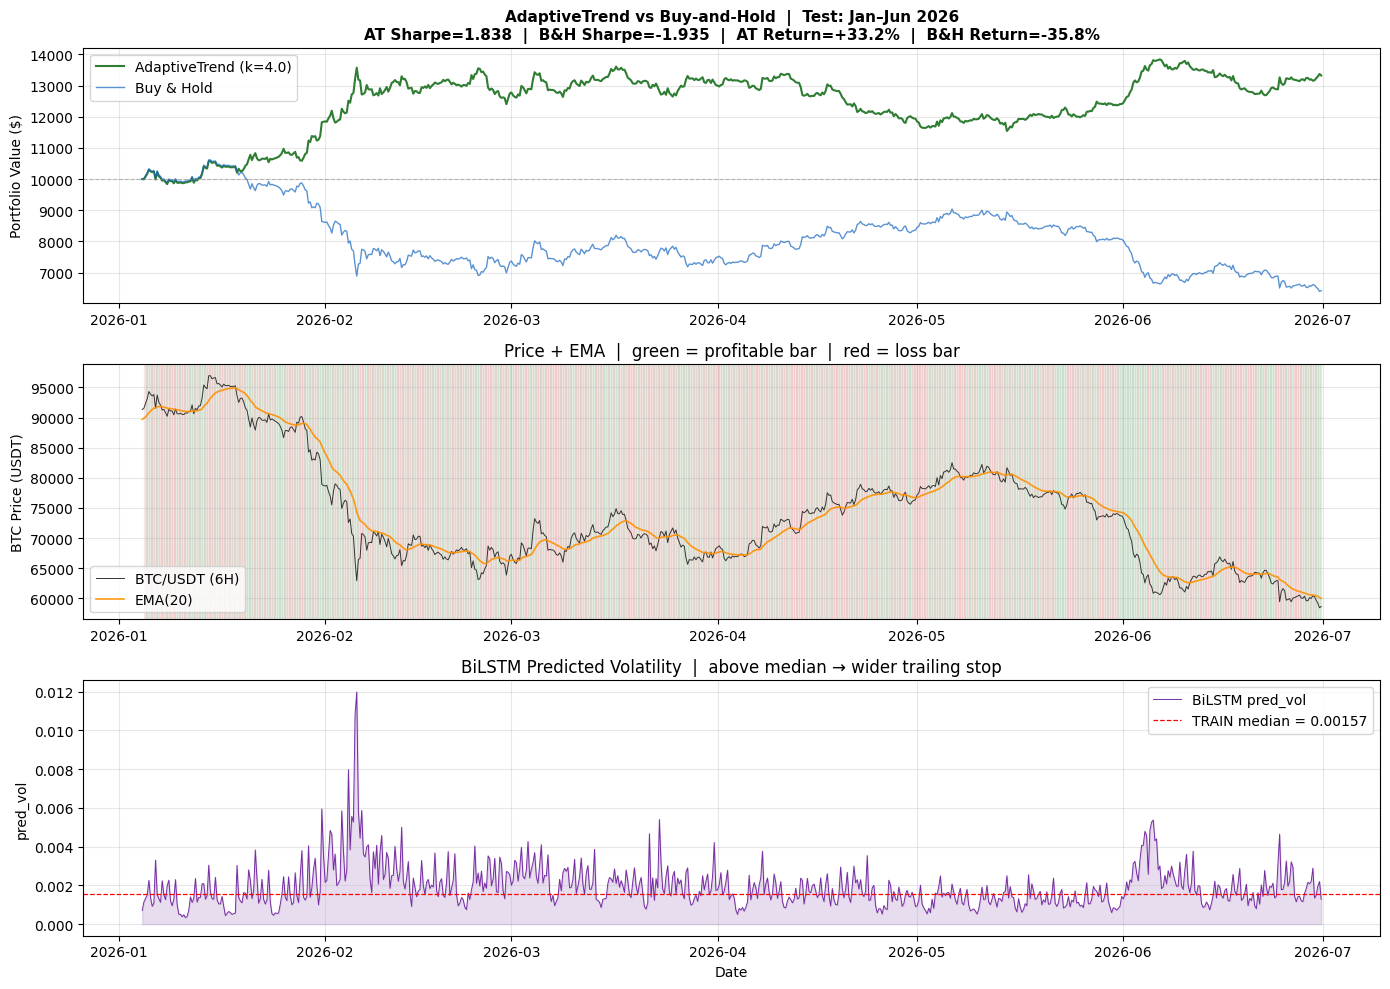

In [40]:
df_bar_pnl = pd.Series(bar_pnl_test, index=df_test_6h.index[:len(bar_pnl_test)])
monthly_at  = df_bar_pnl.resample('ME').sum()

bnh_monthly = (pd.Series(bnh_ret, index=df_test_6h.index[:len(bar_pnl_test)])
               .resample('ME').sum() * CAPITAL)

print('\nMONTHLY RESULTS (Test Period)')
print(f'{"Month":<10} {"AdaptiveTrend":>15} {"B&H":>12} {"Status":>8}')
print('-'*48)
for month in bnh_monthly.index:
    at     = monthly_at.get(month, 0)
    bh     = bnh_monthly.get(month, 0)
    status = '' if at > bh else ''
    print(f'{month.strftime("%Y-%m"):<10} ${at:>14.0f} ${bh:>11.0f}  {status}')

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

min_len  = min(len(eq_test), len(bnh_eq))
eq_dates = df_test_6h.index[-min_len:]

axes[0].plot(eq_dates, eq_test[-min_len:],
             color='#2E7D32', linewidth=1.5, label=f'AdaptiveTrend (k={BEST_K})')
axes[0].plot(eq_dates, bnh_eq[-min_len:],
             color='#1565C0', linewidth=1.0, alpha=0.7, label='Buy & Hold')
axes[0].axhline(CAPITAL, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_title(
    f'AdaptiveTrend vs Buy-and-Hold  |  Test: Jan–Jun 2026\n'
    f'AT Sharpe={res_test["sharpe_bar"]}  |  B&H Sharpe={bnh_sharpe:.3f}  '
    f'|  AT Return={res_test["ret"]:+.1f}%  |  B&H Return={bnh_ret_total:+.1f}%',
    fontsize=11, fontweight='bold')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_test_6h.index, df_test_6h['close'],
             color='#333', linewidth=0.7, label='BTC/USDT (6H)')
axes[1].plot(df_test_6h.index, df_test_6h['EMA'],
             color='#FF8F00', linewidth=1.2, label='EMA(20)', alpha=0.9)
for i in range(len(df_test_6h)-1):
    c = '#2E7D32' if bar_pnl_test[i] > 0 else ('#C62828' if bar_pnl_test[i] < 0 else 'none')
    if c != 'none':
        axes[1].axvspan(df_test_6h.index[i], df_test_6h.index[i+1], alpha=0.08, color=c)
axes[1].set_ylabel('BTC Price (USDT)')
axes[1].set_title('Price + EMA  |  green = profitable bar  |  red = loss bar')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(df_test_6h.index, df_test_6h['pred_vol'],
             color='#6A1B9A', linewidth=0.7, alpha=0.9, label='BiLSTM pred_vol')
axes[2].fill_between(df_test_6h.index, 0, df_test_6h['pred_vol'],
                     color='#6A1B9A', alpha=0.15)
axes[2].axhline(MEDIAN_PV_TRAIN, color='red', linestyle='--', linewidth=0.9,
                label=f'TRAIN median = {MEDIAN_PV_TRAIN:.5f}')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('pred_vol')
axes[2].set_title('BiLSTM Predicted Volatility  |  above median → wider trailing stop')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/Z4_AdaptiveTrend_results.png', dpi=150, bbox_inches='tight')
print('\n Plot saved.')
plt.show()

# FINAL SUMMARY

In [41]:
results = pd.DataFrame({
    'Metric':        ['Sharpe', 'Return', 'Max DD', 'Trades', 'Win Rate'],
    'AdaptiveTrend': [f'{res_test["sharpe_bar"]}', f'{res_test["ret"]:+.2f}%', f'{res_test["max_dd"]:.2f}%', f'{res_test["n_trades"]}', f'{res_test["wr"]:.0%}'],
    'Buy & Hold':    [f'{bnh_sharpe:.3f}', f'{bnh_ret_total:+.2f}%', f'{bnh_max_dd:.2f}%', '-', '-']
})

results.set_index("Metric", inplace=True)
results.index.name = None


print('TEST RESULTS: JAN-JUN 2026')
results

TEST RESULTS: JAN-JUN 2026


,AdaptiveTrend,Buy & Hold
Sharpe,1.838,-1.935
Return,+33.24%,-35.79%
Max DD,-20.68%,-42.21%
Trades,16,-
Win Rate,50%,-
